In [1]:
import sys
print(sys.executable)


c:\Users\Freya Laptop\AppData\Local\Programs\Python\Python310\python.exe


In [7]:
%pip install openpyxl
import pandas as pd

# Load Excel file (first sheet by default)
df = pd.read_excel(r"E:\Cross-Drug Repurposing\dataset.xlsx")

df.head()



Note: you may need to restart the kernel to use updated packages.


,# ChemicalName,ChemicalID,CasRN,DiseaseName,DiseaseID,DirectEvidence,InferenceGeneSymbol,InferenceScore,OmimIDs,PubMedIDs
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,06-Paris-LA-66 protocol,C046983,NaN,Precursor Cell Lymphoblastic Leukemia-Lymphoma,MESH:D054198,therapeutic,NaN,NaN,NaN,4519131
2,10074-G5,C534883,NaN,Adenocarcinoma,MESH:D000230,NaN,MYC,4.08,NaN,26432044
3,10074-G5,C534883,NaN,Adenocarcinoma of Lung,MESH:D000077192,NaN,MYC,4.31,NaN,26656844|27602772
4,10074-G5,C534883,NaN,Alopecia,MESH:D000505,NaN,AR,4.51,NaN,15902657


In [8]:
print(df.columns)

Index(['# ChemicalName', 'ChemicalID', 'CasRN', 'DiseaseName', 'DiseaseID',
       'DirectEvidence', 'InferenceGeneSymbol', 'InferenceScore', 'OmimIDs',
       'PubMedIDs'],
      dtype='object')


In [9]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048548 entries, 0 to 1048547
Data columns (total 10 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   # ChemicalName       1048547 non-null  object 
 1   ChemicalID           1048547 non-null  object 
 2   CasRN                576905 non-null   object 
 3   DiseaseName          1048547 non-null  object 
 4   DiseaseID            1048547 non-null  object 
 5   DirectEvidence       6020 non-null     object 
 6   InferenceGeneSymbol  1042527 non-null  object 
 7   InferenceScore       1042527 non-null  float64
 8   OmimIDs              73583 non-null    object 
 9   PubMedIDs            992962 non-null   object 
dtypes: float64(1), object(9)
memory usage: 80.0+ MB
# ChemicalName               1
ChemicalID                   1
CasRN                   471643
DiseaseName                  1
DiseaseID                    1
DirectEvidence         1042528
InferenceGeneSymbol     

In [10]:
df = df.drop(columns=["ChemicalID", "CasRN", "DiseaseID", "OmimIDs", "PubMedIDs"])


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Load dataset
df = pd.read_excel(r"E:\Cross-Drug Repurposing\dataset.xlsx")


df = df.dropna(subset=["InferenceScore"])


features = ["# ChemicalName", "ChemicalID", "DiseaseName", "DiseaseID", "DirectEvidence", "InferenceGeneSymbol"]
X = df[features].fillna("Unknown")

label_encoders = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le


y = df["InferenceScore"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")


MAE: 23.817658981896173
MSE: 5944.786979264445
RMSE: 77.10244470355298
R² Score: 0.0025029131641375324


C:\Users\Freya Laptop\AppData\Local\Temp\ipykernel_13164\330117888.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.values, y=disease_counts.index, palette="Blues_r")


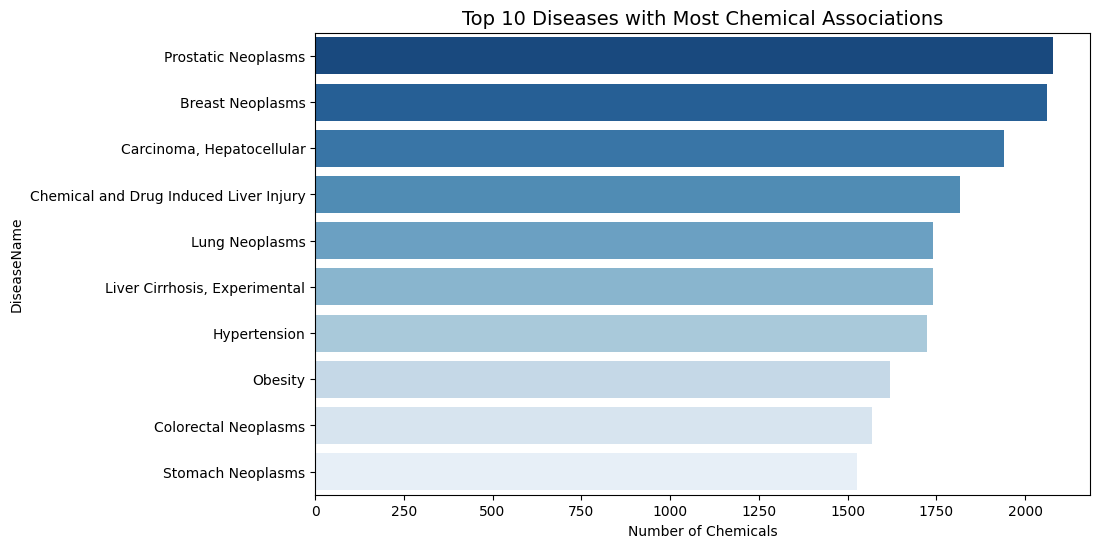

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count number of chemicals per disease
disease_counts = df.groupby("DiseaseName")["ChemicalID"].nunique().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=disease_counts.values, y=disease_counts.index, palette="Blues_r")
plt.title("Top 10 Diseases with Most Chemical Associations", fontsize=14)
plt.xlabel("Number of Chemicals")
plt.ylabel("DiseaseName")
plt.show()


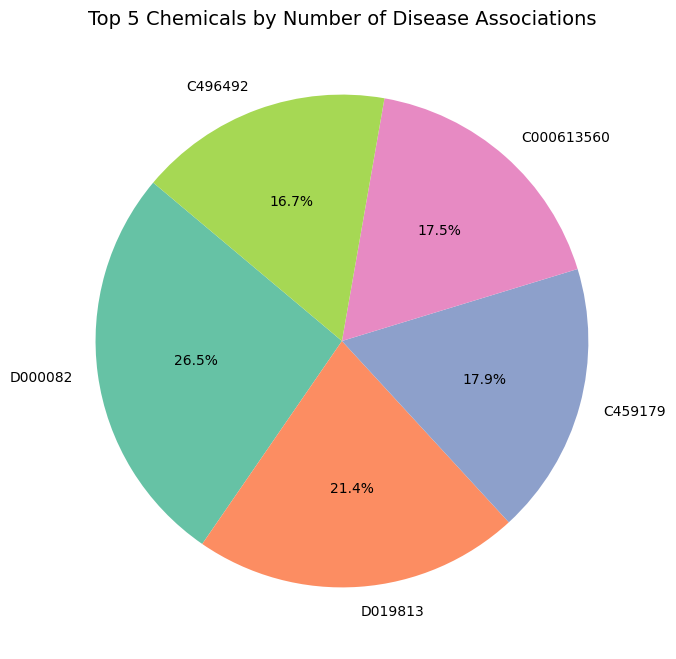

In [17]:
import matplotlib.pyplot as plt

# Count number of diseases per chemical
chemical_counts = df.groupby("ChemicalID")["DiseaseName"].nunique().sort_values(ascending=False).head(5)

# Pie chart
plt.figure(figsize=(8,8))
plt.pie(
    chemical_counts.values, 
    labels=chemical_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Set2.colors
)
plt.title("Top 5 Chemicals by Number of Disease Associations", fontsize=14)
plt.show()


In [19]:
print(df.columns)


Index(['# ChemicalName', 'ChemicalID', 'CasRN', 'DiseaseName', 'DiseaseID',
       'DirectEvidence', 'InferenceGeneSymbol', 'InferenceScore', 'OmimIDs',
       'PubMedIDs'],
      dtype='object')


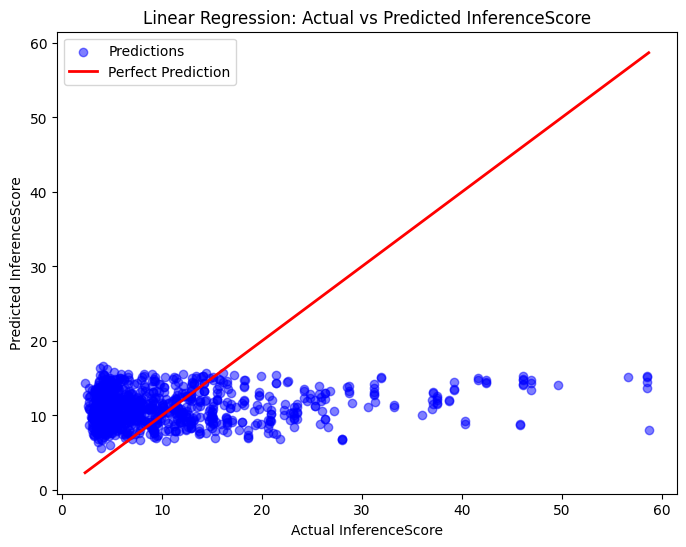

In [22]:
import matplotlib.pyplot as plt

# Scatter plot of actual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color="blue", label="Predictions")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual InferenceScore")
plt.ylabel("Predicted InferenceScore")
plt.title("Linear Regression: Actual vs Predicted InferenceScore")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix, classification_report
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# Use first 5000 and keep needed columns
cols_keep = ['# ChemicalName','ChemicalID','CasRN','DiseaseName','DiseaseID',
             'DirectEvidence','InferenceGeneSymbol','InferenceScore']
df5 = df.loc[:, cols_keep].head(5000).copy()

# Drop rows with missing target
df5 = df5.dropna(subset=['InferenceScore'])

median_score = df5['InferenceScore'].median()
df5['high_score'] = (df5['InferenceScore'] >= median_score).astype(int)

X = df5.drop(columns=['InferenceScore', 'high_score'])
y = df5['high_score']

# Categorical columns (all here are categorical strings)
cat_cols = X.columns.tolist()

# Train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------------
# 3) Common preprocessor: One-Hot encode cats
#    Using sparse output to stay memory-friendly
# ---------------------------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=True), cat_cols)
    ],
    remainder="drop"
)

# ===========================================================
# A) SVM CLASSIFIER (LinearSVC — works with sparse one-hot)
# ===========================================================
svm_clf = Pipeline(steps=[
    ("prep", preprocess),
    ("svm", LinearSVC(C=1.0, random_state=42))
])

svm_clf.fit(X_train, y_train)

# SVM scores (use decision_function for ROC-AUC)
svm_pred = svm_clf.predict(X_test)
svm_dec = svm_clf.decision_function(X_test)

svm_acc = accuracy_score(y_test, svm_pred)
svm_prec, svm_rec, svm_f1, _ = precision_recall_fscore_support(y_test, svm_pred, average="binary", zero_division=0)
svm_auc = roc_auc_score(y_test, svm_dec)

print("=== SVM (LinearSVC) ===")
print(f"Accuracy : {svm_acc:.3f}")
print(f"Precision: {svm_prec:.3f}")
print(f"Recall   : {svm_rec:.3f}")
print(f"F1-score : {svm_f1:.3f}")
print(f"ROC-AUC  : {svm_auc:.3f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))
print()




=== SVM (LinearSVC) ===
Accuracy : 0.804
Precision: 0.776
Recall   : 0.856
F1-score : 0.814
ROC-AUC  : 0.882
Confusion Matrix:
 [[375 124]
 [ 72 429]]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc3 as pm
import arviz as az
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


WARN: Could not locate executable g77
WARN: Could not locate executable f77
WARN: Could not locate executable ifort
WARN: Could not locate executable ifl
WARN: Could not locate executable f90
WARN: Could not locate executable DF
WARN: Could not locate executable efl


c:\Users\Freya Laptop\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


In [6]:
# Drop rows where target is NaN
df = df.dropna(subset=['InferenceScore'])

X = df.drop(columns=['InferenceScore'])
y = df['InferenceScore']

# Convert target to binary classification (high vs low score)
if y.dtype != 'int' and y.dtype != 'object':
    y = pd.qcut(y, q=2, labels=[0,1])


Accuracy: 0.5326561345956471

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.53      0.53    104296
           1       0.53      0.53      0.53    104210

    accuracy                           0.53    208506
   macro avg       0.53      0.53      0.53    208506
weighted avg       0.53      0.53      0.53    208506



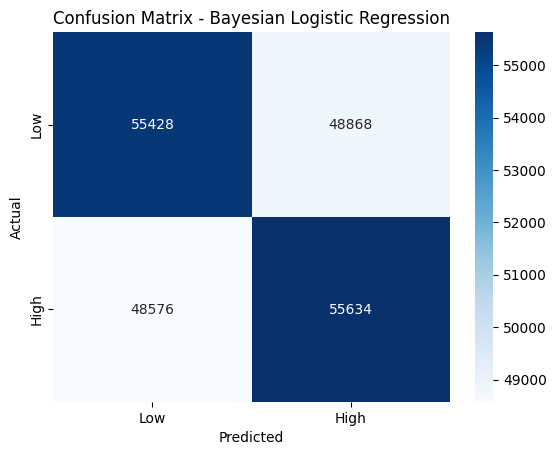

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel(r"E:\Cross-Drug Repurposing\dataset.xlsx")

# Drop rows where target (InferenceScore) is missing
df = df.dropna(subset=["InferenceScore"])

# Select features
features = ["# ChemicalName", "ChemicalID", "DiseaseName", "DiseaseID", "DirectEvidence", "InferenceGeneSymbol"]
X = df[features].fillna("Unknown")

label_encoders = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Target variable 
y = pd.qcut(df["InferenceScore"], q=2, labels=[0, 1])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Bayesian Logistic Regression (L2 penalty acts like Bayesian prior)
bayes_log_reg = LogisticRegression(
    penalty="l2",      # Gaussian prior
    solver="lbfgs",    # supports L2
    max_iter=500
)
bayes_log_reg.fit(X_train, y_train)

# Predictions
y_pred = bayes_log_reg.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix visualization
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Low", "High"], yticklabels=["Low", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Bayesian Logistic Regression")
plt.show()

    

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering   # ✅ added KMeans import
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
print(df.columns.tolist())


['# ChemicalName', 'ChemicalID', 'CasRN', 'DiseaseName', 'DiseaseID', 'DirectEvidence', 'InferenceGeneSymbol', 'InferenceScore', 'OmimIDs', 'PubMedIDs']


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Chemical_encoded'] = le.fit_transform(df['# ChemicalName'])
df['Disease_encoded'] = le.fit_transform(df['DiseaseName'])
df['Gene_encoded'] = le.fit_transform(df['InferenceGeneSymbol'])



In [16]:
from sklearn.preprocessing import StandardScaler

X = df[['Chemical_encoded', 'Disease_encoded', 'Gene_encoded', 'InferenceScore']].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [17]:
df = df[['# ChemicalName', 'DiseaseName', 'InferenceGeneSymbol', 'InferenceScore']].copy()
df.dropna(subset=['# ChemicalName', 'DiseaseName', 'InferenceGeneSymbol', 'InferenceScore'], inplace=True)

# ✅ Step 4: Encode categorical features
le = LabelEncoder()
df['Chemical_encoded'] = le.fit_transform(df['# ChemicalName'])
df['Disease_encoded'] = le.fit_transform(df['DiseaseName'])
df['Gene_encoded'] = le.fit_transform(df['InferenceGeneSymbol'])

# ✅ Step 5: Prepare features for clustering
X = df[['Chemical_encoded', 'Disease_encoded', 'Gene_encoded', 'InferenceScore']]

# Fill any leftover NaN (if InferenceScore had some)
X = X.fillna(X.mean())

# ✅ Step 6: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✅ Step 7: K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

c:\Users\Freya Laptop\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Freya Laptop\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\Freya Laptop\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\Freya Laptop\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Freya Laptop\AppData\Local

In [15]:
# ✅ Step 8: Gaussian Mixture Model
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
df['GMM_Cluster'] = gmm_labels

# Sample down to 2000 rows for hierarchical clustering
sample_df = df.sample(n=2000, random_state=42)
sample_X = X_scaled[:2000]

hier = AgglomerativeClustering(n_clusters=4)
hier_labels = hier.fit_predict(sample_X)
sample_df['Hierarchical_Cluster'] = hier_labels

print("Sample silhouette score:", silhouette_score(sample_X, hier_labels))


Sample silhouette score: 0.39472139059779354


In [18]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

subset_size = 5000  # adjust to your memory limit
indices = np.random.choice(X_scaled.shape[0], subset_size, replace=False)
X_subset = X_scaled[indices]

hier = AgglomerativeClustering(n_clusters=4)
subset_labels = hier.fit_predict(X_subset)

# Optionally attach to a DataFrame for analysis
df_subset = df.iloc[indices].copy()
df_subset['Hierarchical_Cluster'] = subset_labels


In [19]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

print("NumPy version:", np.__version__)
print("SciPy version:", scipy.__version__)
print("All imports successful!")


NumPy version: 2.2.6
SciPy version: 1.15.3
All imports successful!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, AgglomerativeClustering


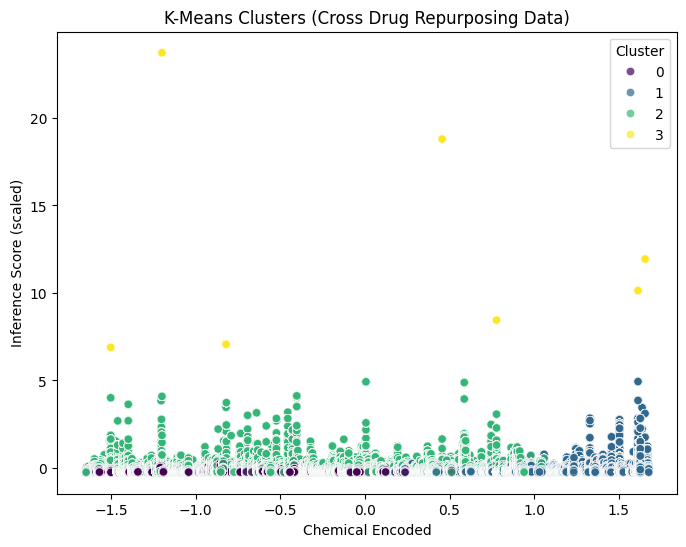

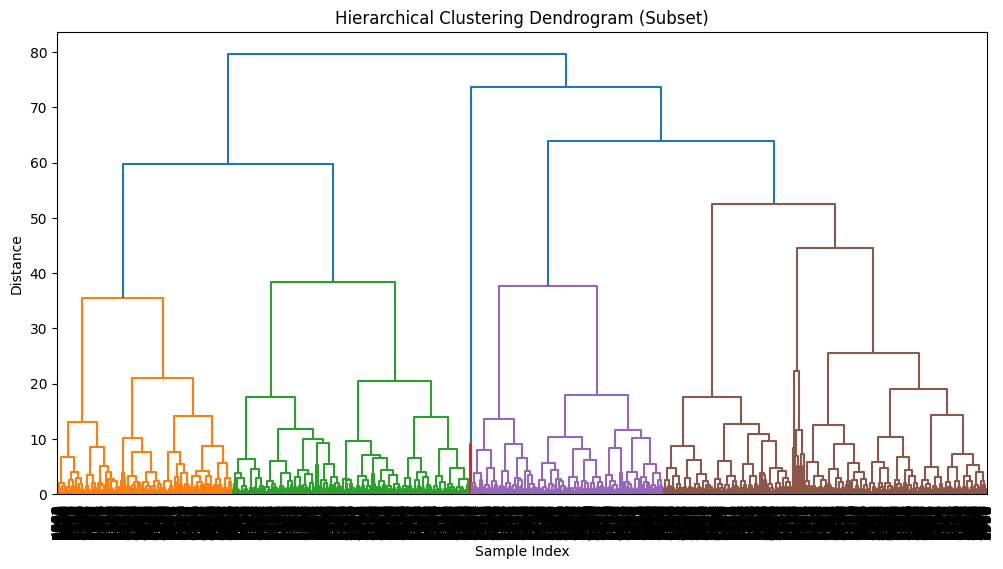

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np
# ✅ Step 6: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✅ Step 7: K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

# -------------------------------
# 1️⃣ K-Means scatter plot
# -------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,3], hue=kmeans_labels, palette='viridis', alpha=0.7)
plt.title("K-Means Clusters (Cross Drug Repurposing Data)")
plt.xlabel("Chemical Encoded")
plt.ylabel("Inference Score (scaled)")
plt.legend(title='Cluster')
plt.show()

# -------------------------------
# 2️⃣ Hierarchical clustering on a subset
# -------------------------------
subset_size = 5000  # adjust to your memory limits
indices = np.random.choice(X_scaled.shape[0], subset_size, replace=False)
X_subset = X_scaled[indices]

# Agglomerative clustering
hier = AgglomerativeClustering(n_clusters=4)
subset_labels = hier.fit_predict(X_subset)

# Dendrogram
linkage_matrix = linkage(X_subset, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=20, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (Subset)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

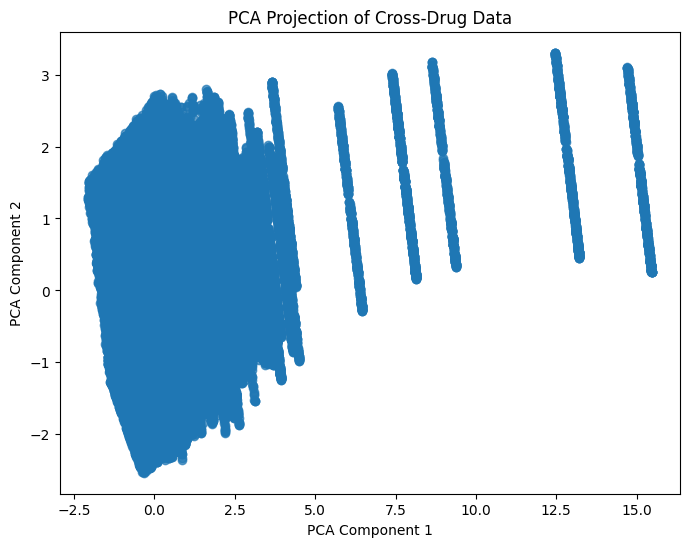

In [21]:

pca = PCA(n_components=2)  # reduce to 2D
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
plt.title("PCA Projection of Cross-Drug Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

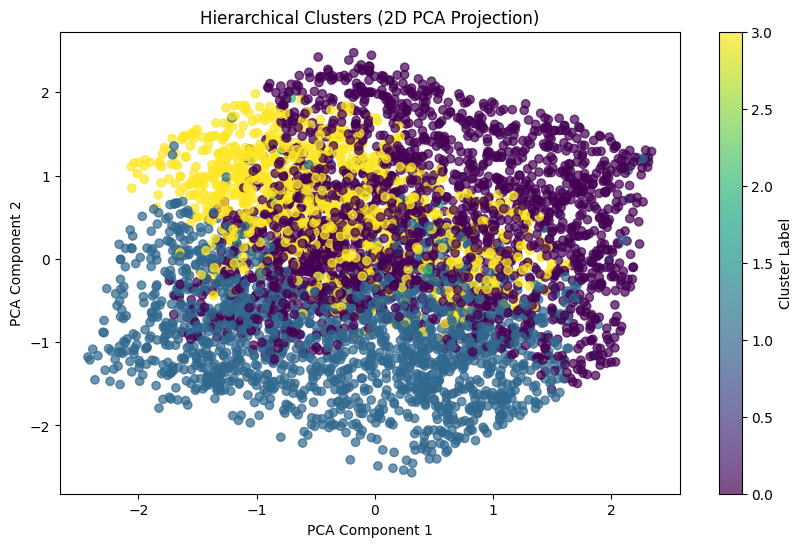

In [22]:
X_subset_pca = pca.fit_transform(X_subset)
plt.figure(figsize=(10,6))
scatter = plt.scatter(X_subset_pca[:,0], X_subset_pca[:,1], c=subset_labels, cmap='viridis', alpha=0.7)
plt.title("Hierarchical Clusters (2D PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label='Cluster Label')
plt.show()

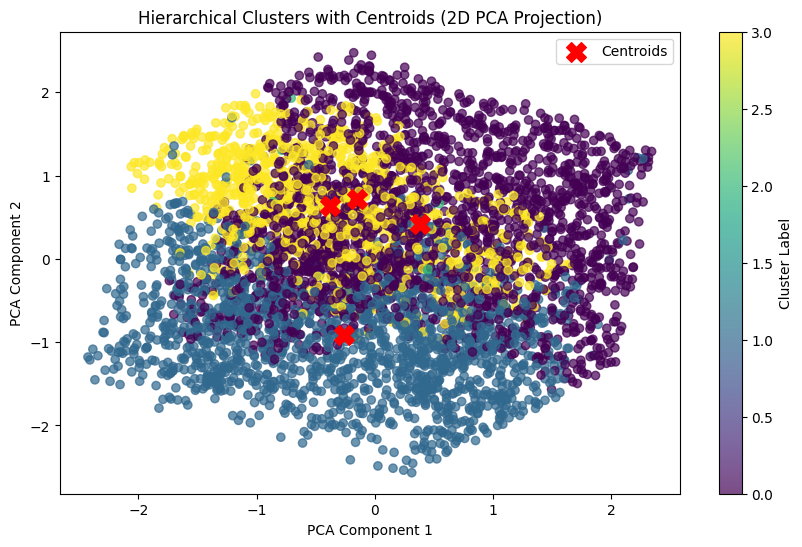

In [24]:
X_subset_pca = pca.fit_transform(X_subset)
plt.figure(figsize=(10,6))
scatter = plt.scatter(X_subset_pca[:,0], X_subset_pca[:,1], c=subset_labels, cmap='viridis', alpha=0.7)

# Compute centroids for hierarchical clusters
centroids_hier = np.array([X_subset_pca[subset_labels==i].mean(axis=0) for i in range(4)])
plt.scatter(centroids_hier[:,0], centroids_hier[:,1], s=200, c='red', marker='X', label='Centroids')

plt.title("Hierarchical Clusters with Centroids (2D PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label='Cluster Label')
plt.legend()
plt.show()

In [26]:
import numpy as np
import pandas as pd
from hmmlearn import hmm
from sklearn.preprocessing import LabelEncoder

# -------------------------------
# Example sequential data: Drug sequences
# -------------------------------
# Let's say each row in df is a sequential interaction
# Here we will simulate a small sequential dataset
df = pd.DataFrame({
    'DrugSequence': ['DrugA', 'DrugB', 'DrugC', 'DrugA', 'DrugC', 'DrugB', 'DrugA', 'DrugC', 'DrugB']
})

# Encode the drugs as integers
le = LabelEncoder()
df['Drug_encoded'] = le.fit_transform(df['DrugSequence'])

# Prepare the sequence for HMM
# hmmlearn expects 2D array (n_samples, n_features), we have 1 feature
X = df['Drug_encoded'].values.reshape(-1, 1)

# -------------------------------
# 3️⃣ Initialize and fit HMM
# -------------------------------
n_states = 3  # number of hidden states
model = hmm.MultinomialHMM(n_components=n_states, n_iter=100, random_state=42)

# Fit the model
model.fit(X)

# -------------------------------
# 4️⃣ Predict hidden states
# -------------------------------
hidden_states = model.predict(X)
df['HiddenState'] = hidden_states

print(df)

# -------------------------------
# 5️⃣ Predict next possible drug
# -------------------------------
# Get probabilities for the next observation from last hidden state
last_state = hidden_states[-1]
next_probabilities = model.emissionprob_[last_state]  # emission probabilities of last state
predicted_next_drug_index = np.argmax(next_probabilities)
predicted_next_drug = le.inverse_transform([predicted_next_drug_index])[0]

print(f"Predicted next drug in sequence: {predicted_next_drug}")


MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


  DrugSequence  Drug_encoded  HiddenState
0        DrugA             0            1
1        DrugB             1            0
2        DrugC             2            1
3        DrugA             0            0
4        DrugC             2            1
5        DrugB             1            0
6        DrugA             0            1
7        DrugC             2            0
8        DrugB             1            1
Predicted next drug in sequence: DrugA


In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt


In [29]:
# Keep relevant columns
df = df[['# ChemicalName', 'DiseaseName', 'InferenceGeneSymbol', 'InferenceScore']].copy()
df.dropna(subset=['# ChemicalName', 'DiseaseName', 'InferenceGeneSymbol', 'InferenceScore'], inplace=True)

# Encode categorical variables
le = LabelEncoder()
df['Chemical_encoded'] = le.fit_transform(df['# ChemicalName'])
df['Disease_encoded'] = le.fit_transform(df['DiseaseName'])
df['Gene_encoded'] = le.fit_transform(df['InferenceGeneSymbol'])

# Feature matrix and target
X = df[['Chemical_encoded', 'Disease_encoded', 'Gene_encoded', 'InferenceScore']]
y = df['Disease_encoded'] 


KeyError: "None of [Index(['# ChemicalName', 'DiseaseName', 'InferenceGeneSymbol',\n       'InferenceScore'],\n      dtype='object')] are in the [columns]"